# Aprendizado de Máquina e Reconhecimento de Padrões

Teoria de Probabilidades e Distribuições Estatísticas

Experimentos Computacionais - `Python`

Material produzido por Prof. Dr. Rodrigo Colnago Contreras

Unifesp

# Imports

In [1]:
# Importação de pacotes e submódulos
import numpy as np
from scipy.stats import randint, bernoulli, binom, poisson, uniform, norm, chi2
import random

# Práticas Resolvidas

**Prática 1**: Seja a variável aleatória $X$ com distribuição abaixo:

$$P(X=0) = 0.2,\quad P(X=1) = 0.2, \quad P(X = 2) = 0.6.$$

(a) Calcule $E(X)$ e $V(X)$.

**\#Solução**:~>

**(a)**

O valor esperado:$$E[X] = 0\cdot 0.2 + 1\cdot 0.2 + 2\cdot 0.6 = 1.4.$$

A variância: $$V(X) = E[X^2]-E[X]^2 = \left(0^2\cdot 0.2 + 1^2\cdot 0.2 + 2^2\cdot 0.6\right) - 1.4^2 = 2.6 - 1.96 = 0.64.$$



(b) Uma possível representação para $X$ é a listagem $[0,0,1,1,2,2,2,2,2,2]$. Utilizando a função `choice` do pacote `random`, que escolhe aleatoriamente um elemento de um conjunto dado, crie uma lista com `n` observações de $X$ e calcule a média e a variância dessa lista utilizando, respectivamente, as funções `mean` e `std**2` do pacote `numpy` (`np`). Obs.: Considere para `n` os valores $10$, $100$ e $10000$. O que observamos com essa configuração?

**\#Solução**:~>

**(b)**
    

In [2]:
n = 10000000
X = [0,0,1,1,2,2,2,2,2]
x_obs = []
for i in range(0,n):
    x_obs.append(random.choice(X))


Ex = np.mean(x_obs)
Vx = np.std(x_obs)**2
print('Valor esperado de X:', Ex)
print('Variância de X:', Vx)

Valor esperado de X: 1.332929
Variância de X: 0.6668482809590011


Quanto maior o valor de `n`, mais próximo do valor teórico são os valores de média e variância das observações.

**Prática 2**: Em uma urna, há 8 bolas amarelas e 4 verdes. Retiram-se 5 bolas *com reposição*. Utilizando o submódulo `binom`, função `pmf`, do `scipy.stats`, calcule a probabilidade de que:

 (a) Saiam duas bolas amarelas.

**\#Solução~>**

Inicialmente, vale ressaltar que o experimento de se retirar uma bola e constatar sua coloração pode ser interpretado como um ensaio de **Bernoulli** com probabilidade $p$ de se retirar a bola de cor desejada. No caso, o sucesso consiste de retirar uma bola amarela. Então, $p = \frac{8}{8+4} = \frac{8}{12} = \frac{2}{3}$. Agora, como vamos conduzir $n=5$ ensaios, então a distribuição do experimento se trata de uma binomial com $p=2/3$ e $n=5$.

Se queremos $2$ bolas amarelas retiradas entre $5$ bolas, então a probabilidade de isso acontecer é $b(k;n,p) = b(2;5,2/3)$ = `binom.pmf(2,5,2/3)`.

In [3]:
P = binom.pmf(2,5,2/3)
print("A probabilidade é ", round(P*100,2), "%")

A probabilidade é  16.46 %


(b) Saiam, pelo menos, $3$ verdes.

**\#Solução~>**

Neste caso, sair, pelo menos, $3$ bolas verdes representa que vamos nos deparar com, pelo menos, $3$ fracassos, ou, no máximo, $n-k = 5-3 = 2$ sucessos. Assim, precisamos determinar e somar as probabilidades de obtermos:
1. Nenhuma bola amarela;
2. Apenas uma bola amarela,
3. Duas bolas amarelas.

Assim,

In [4]:
P = binom.pmf(0,5,2/3) + binom.pmf(1,5,2/3) + binom.pmf(2,5,2/3)
print("A probabilidade deste evento ocorrer é: b(0,5,2/3) + b(1,5,2/3) + b(2,5,2/3) = ", round(P*100,2), "%")

A probabilidade deste evento ocorrer é: b(0,5,2/3) + b(1,5,2/3) + b(2,5,2/3) =  20.99 %


Obs.: A função `cdf` da distribuição calcula justamente a somatória das probabilidades até certo limiar. Isto é, no lugar de calcularmos a soma, poderíamos fazer o seguinte:

In [5]:
P = binom.cdf(2,5,2/3)
print("A probabilidade deste evento ocorrer é: P(X<=2) = ", round(P*100,2), "%")

A probabilidade deste evento ocorrer é: P(X<=2) =  20.99 %


**Prática 3**: Em uma central telefônica, chegam $5$ chamadas por minuto. Utilizando o submódulo `poisson`, função `pmf`, do `scipy.stats`, calcule a probabilidade de que:

(a) Em um minuto não ocorra nenhuma chamada.

**\#Solução~>**

Temos que o número de chamadas é uma VAD $X\sim \text{Pois}(5)$, pois $\lambda = 5$ indica o valor esperado de ligações por minuto. Queremos calcular a $P(X = 0)$. Assim,

In [6]:
LAMBDA = 5
X = 0
P_x = poisson.pmf(X, LAMBDA)
print("A probabilidade é P(X = 0) = ", round(P_x*100,2), "%")

A probabilidade é P(X = 0) =  0.67 %


(b) Em dois minutos ocorram duas chamadas.

**\#Solução~>**

Neste caso, o intervalo de tempo considerado é $2$ minutos e a frequência de ligação para este intervalo é de $10$ chamadas. Então, o número de chamadas é uma VAD  $X\sim\text{Pois}(10)$, pois  $\lambda=10$  indica o valor esperado de ligações a cada $2$ minutos. Queremos calcular a  P(X=2) . Assim,

In [7]:
LAMBDA = 10
X = 2
P_x = poisson.pmf(X, LAMBDA)
print("A probabilidade é P(X = 2) = ", round(P_x*100,2), "%")

A probabilidade é P(X = 2) =  0.23 %


**Prática 4**: O peso médio de $500$ estudantes do sexo masculino de uma determinada universidade é $75.5$ Kg e o desvio padrão é $7.5$ Kg. Admitindo que os pesos são normalmente distribuídos, determine a percentagem de estudantes que pesam:

(a) entre $60$ e $77.5$ Kg.

**Dica:** Utilize a função `cdf` do submódulo `scipy.stats.norm` para calcular as probabilidades.

**\#Solução:~>**

$$
P(60 \leq X \leq 77.5) = P\left(\frac{60-\mu}{\sigma} \leq \frac{X-\mu}{\sigma} \leq \frac{77.5-\mu}{\sigma}\right)=P\left(\frac{60-\mu}{\sigma} \leq Z \leq \frac{77.5-\mu}{\sigma}\right) =
$$
$$
= P\left(Z \leq \frac{77.5-\mu}{\sigma}\right)-P\left( Z \leq \frac{60-\mu}{\sigma}\right).
$$

In [8]:
media = 75.5
dp = 7.5
a = (60-media)/dp
b = (77.5-media)/dp
P_x = norm.cdf(b)-norm.cdf(a)
print('Probabilidade:', round(100*P_x,2),"%")

Probabilidade: 58.58 %


(b) mais do que $92.5$ Kg.

**\#Solução:~>**


$$
P(X \geq 92,5) = P\left( \frac{X-\mu}{\sigma}\geq \frac{92.5-\mu}{\sigma}\right) = P\left( Z \geq \frac{92.5-\mu}{\sigma}\right) = 1 - P\left( Z < \frac{92.5-\mu}{\sigma}\right).
$$

In [9]:
media = 75.5
dp = 7.5
z = (92.5-media)/dp
P_x = 1-norm.cdf(z)
print('Probabilidade:', round(100*P_x,2),"%")

Probabilidade: 1.17 %


**Prática 5**: Sabe-se que o peso de um grupo de leitões de mesma idade alimentados com determinada ração segue uma distribuição $\chi^2$ com $50$ graus de liberdade. Utilizando a `cdf` do submódulo `scipy.stats.chi2`, calcule:

(a) A probabilidade de um leitão desse grupo pesar menos de $30$kg.

**\#Solução:~>**

Queremos calcular o seguinte valor: $P(X < 30)$ para $X\sim \chi^2(50)$.

In [10]:
v = 50
X_lim = 30
P_x = chi2.cdf(X_lim, v)

print('A probabilidade de um leitão pesar menos de 30kg é: ', round(100*P_x,2), "%")

A probabilidade de um leitão pesar menos de 30kg é:  1.12 %


(b) A probabilidade de um leitão desse grupo pesar mais de $50$kg.

**\#Solução~>**

Queremos calcular o seguinte valor: $P(X \geq 50) = 1 - P(X < 50)$ para $X\sim \chi^2(50)$.

In [11]:
v = 50
X_lim = 50
P_x = 1-chi2.cdf(X_lim, v)

print('A probabilidade de um leitão pesar mais de 50kg é: ', round(100*P_x,2), "%")

A probabilidade de um leitão pesar mais de 50kg é:  47.34 %


# Práticas Propostas

**Prática 6**: Calcule a esperança, a variância e o desvio padrão da VAC $X$ que é definida pela seguinte FDP:

$$f(x) = \left\{\begin{matrix}\frac{1}{b-a}, b\leq x\leq a,\\ 0, \text{caso contrário}. \end{matrix}\right.$$

Além disso, comprove que $f \geq 0$ e $\int_{-\infty}^{+\infty} f(x) \text{d}x = 1$.


**Obs**.: $X$ é conhecida como VAC com **distribuição uniforme**.

--- Comprovações Iniciais ---
1. Integral de f(x) de a até b: -a/(-a + b) + b/(-a + b)
2. Esperança E[X]: a/2 + b/2
3. Variância Var(X): a**2/12 - a*b/6 + b**2/12
4. Desvio Padrão: sqrt(a**2/12 - a*b/6 + b**2/12)


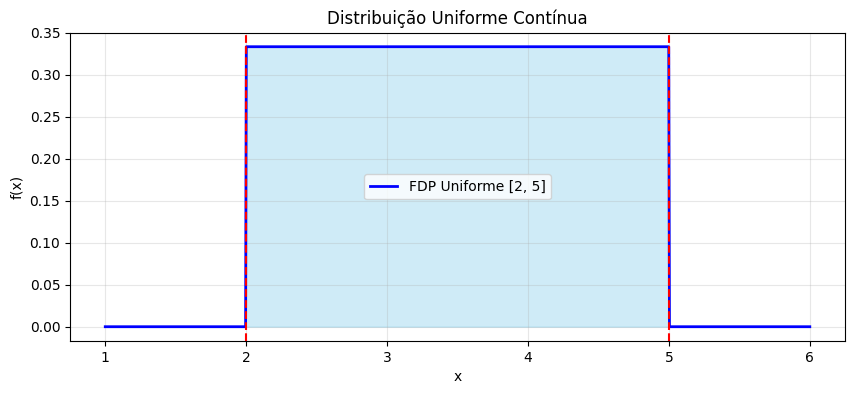

In [12]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1. Definição Simbólica
x, a, b = sp.symbols('x a b')
f = 1 / (b - a)

print("--- Comprovações Iniciais ---")

# A) Integral de f(x) de a até b
integral_fdp = sp.integrate(f, (x, a, b))
print(f"1. Integral de f(x) de a até b: {integral_fdp}")

# 2. Cálculos das Métricas
# B) Esperança: E[X] = Integral de x * f(x)
esperanca = sp.integrate(x * f, (x, a, b))
esperanca_simplificada = sp.simplify(esperanca)
print(f"2. Esperança E[X]: {esperanca_simplificada}")

# C) Variância: Var(X) = E[X^2] - (E[X])^2
e_x2 = sp.integrate(x**2 * f, (x, a, b))
variancia = e_x2 - esperanca**2
variancia_simplificada = sp.simplify(variancia)
print(f"3. Variância Var(X): {variancia_simplificada}")

# D) Desvio Padrão: sqrt(Var(X))
desvio_padrao = sp.sqrt(variancia_simplificada)
print(f"4. Desvio Padrão: {desvio_padrao}")

# --- 3. Visualização Numérica ---
def plot_uniforme(lim_a, lim_b):
    x_val = np.linspace(lim_a - 1, lim_b + 1, 1000)
    # Define f(x) = 1/(b-a) dentro do intervalo e 0 fora
    y_val = np.where((x_val >= lim_a) & (x_val <= lim_b), 1/(lim_b - lim_a), 0)

    plt.figure(figsize=(10, 4))
    plt.plot(x_val, y_val, 'b-', lw=2, label=f'FDP Uniforme [{lim_a}, {lim_b}]')
    plt.fill_between(x_val, y_val, color='skyblue', alpha=0.4)
    plt.axvline(lim_a, color='red', linestyle='--')
    plt.axvline(lim_b, color='red', linestyle='--')
    plt.title("Distribuição Uniforme Contínua")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Exemplo com a=2 e b=5
plot_uniforme(2, 5)

**Prática 7**: Uma máquina de bebidas está regulada de modo a servir uma média de $150$ml por copo. Se a quantidade servida por copo seguir uma distribuição normal com desvio padrão de $20$ml, determine a percentagem de copos que conterão mais de $175$ml de bebida.

Z-score: 1.25
Porcentagem de copos > 175ml: 10.56%


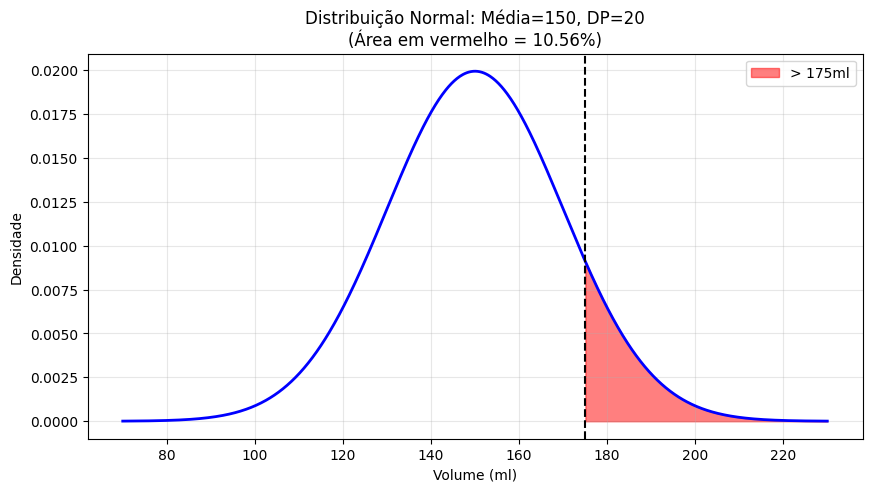

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parâmetros do problema
mu = 150
sigma = 20
x_limite = 175

# 1. Calculando a probabilidade usando a Função de Distribuição Acumulada (CDF)
# norm.cdf(x, mu, sigma) dá a probabilidade à esquerda.
# Para pegar a direita (mais de 175ml), usamos o complemento ou a função sf (survival function).
probabilidade = 1 - norm.cdf(x_limite, mu, sigma)
porcentagem = probabilidade * 100

print(f"Z-score: {(x_limite - mu) / sigma}")
print(f"Porcentagem de copos > 175ml: {porcentagem:.2f}%")

# 2. Visualização
x_axis = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y_axis = norm.pdf(x_axis, mu, sigma)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_axis, 'b-', lw=2)
plt.fill_between(x_axis, y_axis, where=(x_axis > x_limite), color='red', alpha=0.5, label='> 175ml')
plt.axvline(x_limite, color='black', linestyle='--')
plt.title(f"Distribuição Normal: Média=150, DP=20\n(Área em vermelho = {porcentagem:.2f}%)")
plt.xlabel("Volume (ml)")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Prática 8**: Sabe-se, de dados anteriores, que o período, em meses, entre as reclamações de clientes sobre certo produto tem distribuição $\chi^2$ com $4$ graus de liberdade. Foram realizadas mudanças que envolveram um aumento nas condições de controle de qualidade. Depois dessas mudanças, a primeira reclamação de cliente ocorreu depois de $20$ meses. O aumento no controle de qualidade parece ter surtido efeito?

Probabilidade de observar uma reclamação após 20 meses: 0.000499
Conclusão: O aumento no controle de qualidade PARECE ter surtido efeito (Evento raro).


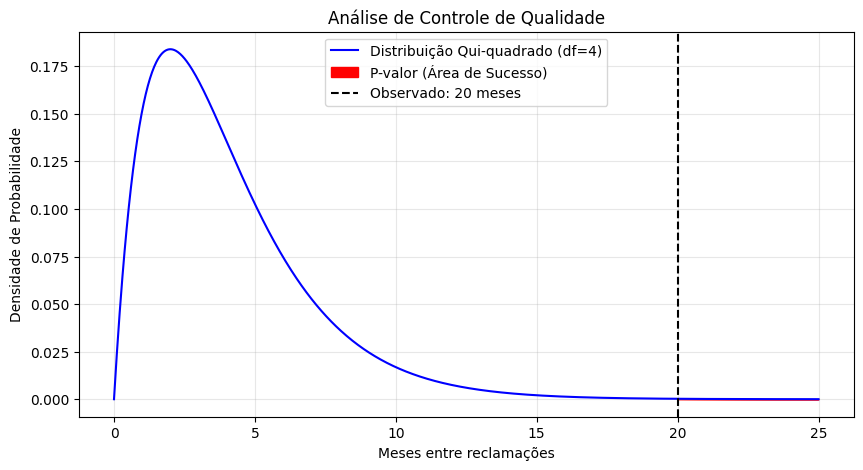

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parâmetros
graus_liberdade = 4
valor_observado = 20

# 1. Calculando o P-valor (Probabilidade de X >= 20)
# chi2.sf é a Survival Function (1 - CDF), que dá a área à direita
p_valor = chi2.sf(valor_observado, graus_liberdade)

print(f"Probabilidade de observar uma reclamação após 20 meses: {p_valor:.6f}")

if p_valor < 0.05:
    print("Conclusão: O aumento no controle de qualidade PARECE ter surtido efeito (Evento raro).")
else:
    print("Conclusão: Não há evidências estatísticas de que o controle mudou o processo.")

# 2. Visualização Gráfica
x = np.linspace(0, 25, 1000)
y = chi2.pdf(x, graus_liberdade)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b-', label=f'Distribuição Qui-quadrado (df={graus_liberdade})')
plt.fill_between(x, y, where=(x >= valor_observado), color='red', label='P-valor (Área de Sucesso)')
plt.axvline(valor_observado, color='black', linestyle='--', label=f'Observado: {valor_observado} meses')

plt.title("Análise de Controle de Qualidade")
plt.xlabel("Meses entre reclamações")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Prática 9**: Gafanhotos distribuem-se aleatoriamente em um vasto campo, de acordo com uma distribuição de Poisson, com parâmetro $\lambda = 2$ por jarda quadrada. Qual é o tamanho do raio $R$ de uma região amostral circular para que a probabilidade de se encontrar pelo menos um gafanhoto na região seja de $0.99$?

In [15]:
import numpy as np
import scipy.stats as stats

# Dados do problema
taxa_por_jarda = 2
prob_alvo = 0.99

# 1. Encontrar o Lambda necessário
# 1 - exp(-lambda) = 0.99  =>  exp(-lambda) = 0.01
lamb_necessario = -np.log(1 - prob_alvo)

# 2. Calcular o Raio R
# lambda = taxa * Area => lambda = 2 * pi * R^2
raio = np.sqrt(lamb_necessario / (taxa_por_jarda * np.pi))

print(f"O parâmetro Lambda necessário é: {lamb_necessario:.4f}")
print(f"O raio R da região circular deve ser: {raio:.4f} jardas")

# --- Verificação ---
area = np.pi * (raio**2)
lamb_final = taxa_por_jarda * area
prob_pelo_menos_um = 1 - stats.poisson.pmf(0, lamb_final)

print(f"\nConferência:")
print(f"Probabilidade calculada com R={raio:.4f}: {prob_pelo_menos_um:.4f}")

O parâmetro Lambda necessário é: 4.6052
O raio R da região circular deve ser: 0.8561 jardas

Conferência:
Probabilidade calculada com R=0.8561: 0.9900


**Prática 10**: Certo teste de presença de uma certa doença tem probabilidade $0.20$ de fornecer um resultado positivo falso (indicando que o indivíduo tem a doença quando não for o caso) e probabilidade $0.10$ de fornecer um resultado negativo falso. Suponha que $10$ indivíduos sejam testados, cinco dos quais têm a doença e cinco não. Seja $X$ o número de resultados positivos.

(a) $X$ tem distribuição binomial? Explique seu raciocínio.

(b) Qual é a probabilidade de exatamente três dos $10$ resultados serem positivos?

In [16]:
from scipy.stats import binom

# Parâmetros
n_doentes = 5
p_doentes = 0.90  # Verdadeiro Positivo (1 - 0.10 falso negativo)

n_saudaveis = 5
p_saudaveis = 0.20 # Falso Positivo

total_alvo = 3
probabilidade_total = 0

print("Cenários possíveis para total = 3:")

# Loop para as combinações (i + j = 3)
for i in range(total_alvo + 1):
    j = total_alvo - i

    # i = positivos do grupo doente, j = positivos do grupo saudável
    p_i = binom.pmf(i, n_doentes, p_doentes)
    p_j = binom.pmf(j, n_saudaveis, p_saudaveis)

    prob_cenario = p_i * p_j
    probabilidade_total += prob_cenario

    print(f"- Doentes: {i}, Saudáveis: {j} | Prob: {prob_cenario:.6f}")

print(f"\nProbabilidade exata de 3 resultados positivos: {probabilidade_total:.6f}")
print(f"Ou seja, aproximadamente {probabilidade_total*100:.2f}%")

Cenários possíveis para total = 3:
- Doentes: 0, Saudáveis: 3 | Prob: 0.000001
- Doentes: 1, Saudáveis: 2 | Prob: 0.000092
- Doentes: 2, Saudáveis: 1 | Prob: 0.003318
- Doentes: 3, Saudáveis: 0 | Prob: 0.023888

Probabilidade exata de 3 resultados positivos: 0.027298
Ou seja, aproximadamente 2.73%
